In [1]:
import numpy as np 
import pandas as pd 

In [2]:
data = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"

df = pd.read_csv(data) 
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [3]:
df.dtypes

model_year               int64
origin                     str
fuel_type                  str
drivetrain                 str
num_doors                int64
engine_displacement      int64
num_cylinders            int64
horsepower             float64
vehicle_weight           int64
acceleration           float64
fuel_efficiency_mpg    float64
dtype: object

In [4]:
cols_categorical = list(df.dtypes[df.dtypes == 'str'].index)
cols_categorical

['origin', 'fuel_type', 'drivetrain']

In [5]:
for cols in cols_categorical: 
    print (df[cols].unique()) 
    print ()
    print (df[cols].nunique())

<StringArray>
['Europe', 'Asia', 'USA']
Length: 3, dtype: str

3
<StringArray>
['Gasoline', 'Diesel', 'Hybrid']
Length: 3, dtype: str

3
<StringArray>
['Front-wheel drive', 'Rear-wheel drive', 'All-wheel drive']
Length: 3, dtype: str

3


In [6]:
print (df['num_doors'].unique())
print (df['num_cylinders'].unique())

[4 5 3 2]
[6 7 5 8 4]


### Question 1 

In [7]:
df.isna().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

### Question 2 

In [8]:
df.describe()

,model_year,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
count,10000.000000,10000.00000,10000.000000,10000.000000,9123.000000,10000.000000,9736.000000,10000.000000
mean,1999.549500,3.50400,2268.807000,6.035200,254.446016,4286.754000,18.888044,29.997700
std,14.207925,0.95209,183.447355,0.542578,22.844613,266.212491,1.279543,2.930245
min,1975.000000,2.00000,1590.000000,4.000000,171.000000,3320.000000,14.000000,19.800000
25%,1987.000000,3.00000,2150.000000,6.000000,239.000000,4110.000000,18.000000,28.000000
50%,2000.000000,4.00000,2270.000000,6.000000,254.000000,4280.000000,18.900000,30.000000
75%,2012.000000,4.00000,2390.000000,6.000000,270.000000,4470.000000,19.700000,31.900000
max,2024.000000,5.00000,3110.000000,8.000000,334.000000,5460.000000,23.800000,41.200000


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

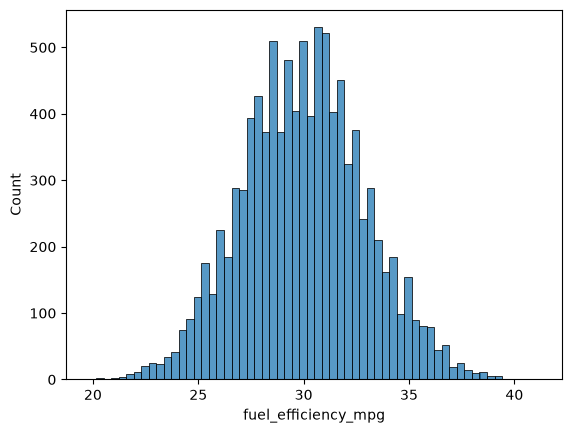

In [10]:
sns.histplot(df.fuel_efficiency_mpg) 

### Splitting dataset to train, validation, and test sets 

In [11]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [12]:
n= len(df)

n_val = int(n*0.2) # 20% validation set
n_test = int(n*0.2) # 20% test set
n_train = n - n_val - n_test

In [13]:
n_train

6000

In [14]:
n_val, n_test, n_train

(2000, 2000, 6000)

In [15]:
np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

df_train = df_train.reset_index(drop=True) 
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

In [18]:
del df_train ['fuel_efficiency_mpg']
del df_val ['fuel_efficiency_mpg']
del df_test ['fuel_efficiency_mpg']

In [19]:
df_train.columns

Index(['model_year', 'origin', 'fuel_type', 'drivetrain', 'num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration'],
      dtype='str')

### Question 3

### Create Linear Regression Model

In [20]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
]

X = np.array(X)
X

array([[ 148,   24, 1385],
       [ 132,   25, 2031],
       [ 453,   11,   86],
       [ 158,   24,  185],
       [ 172,   25,  201],
       [ 413,   11,   86],
       [  38,   54,  185],
       [ 142,   25,  431],
       [ 453,   31,   86]])

In [21]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [22]:

def linear_regression (X,y): 
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X]) 
    
    XTX = X.T.dot(X)
    
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    return w_full[0], w_full[1:]

In [23]:
linear_regression (X, y)

(np.float64(25844.754055766833),
 array([ -16.08906468, -199.47254894,   -1.22802883]))

In [24]:
base = ['model_year','num_doors',
       'engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration'] 
X_train = df_train[base].fillna(0).values

w0, w = linear_regression (X_train, y_train) 

y_pred = w0 + X_train.dot(w)

In [25]:
y_pred

array([33.99817336, 29.28417937, 32.92074286, ..., 29.29080277,
       31.97094714, 29.63201577], shape=(6000,))

<Axes: ylabel='Count'>

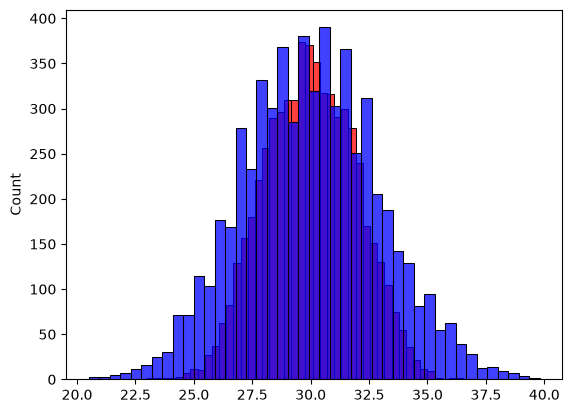

In [26]:
sns.histplot(y_pred, color='red')
sns.histplot(y_train, color='blue')

In [27]:
def rmse (y, y_pred): 
    se = (y - y_pred) ** 2 
    mse = se.mean()
    return np.sqrt(mse)

In [28]:
print (rmse (y_train, y_pred))

2.1978313438426755


In [29]:
def prepare_zero(df):
    df = df.copy()
    df_zero = df[base]
    df_zero = df_zero.fillna(0)
    X = df_zero.values
    return X

In [30]:
X_train = prepare_zero(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_zero(df_val)
y_pred = w0 + X_val.dot(w)
print (round (rmse(y_val, y_pred), 3))

2.205


In [31]:
def prepare_mean(df):
    df = df.copy()
    df_mean = df[base]
    df_mean = df_mean.fillna(df_mean.mean())
    X = df_mean.values
    return X

In [32]:
X_train = prepare_mean(df_train)
w0, w = linear_regression(X_train, y_train)

X_val = prepare_mean(df_val)
y_pred = w0 + X_val.dot(w)
print (round (rmse(y_val, y_pred), 3))

2.201


### Question 4

### Regularization

In [33]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5.00000001],
]

X = np.array(X)
X

array([[4.        , 4.        , 4.        ],
       [3.        , 5.        , 5.        ],
       [5.        , 1.        , 1.        ],
       [5.        , 4.        , 4.        ],
       [7.        , 5.        , 5.        ],
       [4.        , 5.        , 5.00000001]])

In [34]:
y= [1, 2, 3, 1, 2, 3]

In [35]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [36]:
X_train = prepare_zero(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_zero(df_val)
y_pred = w0 + X_val.dot(w)
print (rmse(y_val, y_pred))

2.2051856879530947


In [37]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_zero(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_zero(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(round(score,4))

2.2047
2.2052
2.2233
2.3469
2.4062
2.4162
2.4257


### Question 5

In [38]:
score_list = []
for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]: 
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]
    
    df_train = df_train.reset_index(drop=True) 
    df_val = df_val.reset_index(drop=True)
    df_test = df_test.reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values


    X_train = prepare_zero(df_train)
    w0, w = linear_regression(X_train, y_train)
    X_val = prepare_zero(df_val)
    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val,y_pred)
    score_list.append(score)
    score_array = np.array(score_list)
    score_pd = pd.DataFrame(score_array, columns=['RMSE']) 
    std = np.std (score_pd)
    
    
print (round (std, 3))

0.031


### Question 6

In [39]:
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)
    
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]
    
df_train = df_train.reset_index(drop=True) 
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)

y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_zero(df_full_train)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_zero(df_test) 
y_pred = w0 + X_test.dot(w)

score = rmse(y_test,y_pred)

print (round (score,3))

2.235
